<a href="https://colab.research.google.com/github/VijayReddy-07/Drug-Review-System/blob/main/drug_Review_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('drugsComTrain_raw.csv')

In [ ]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
df.tail()

,uniqueID,drugName,condition,review,rating,date,usefulCount
77487,155815,Metronidazole,Bacterial Vaginitis,"""I&#039;m on day 3 of 7. So far, it&#039;s bee...",9,7-Jan-12,15
77488,159817,Bactrim,Bacterial Skin Infection,"""Had cut my foot at a beach and was prescribed...",1,11-Apr-16,15
77489,191161,Niaspan,High Cholesterol,"""Posted about a year ago here after I first st...",4,16-Jul-14,16
77490,163357,Acetaminophen / dichloralphenazone / isomethep...,Headache,"""Midrin was the only thing that helped my migr...",10,10-Mar-12,13
77491,165159,Phentermine / topiramate,Weight Loss,"""I lost 80 pounds in 6 months. I lost a little...",9,4-Aug-15,32


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77492 entries, 0 to 77491
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uniqueID     77492 non-null  int64 
 1   drugName     77492 non-null  object
 2   condition    77032 non-null  object
 3   review       77492 non-null  object
 4   rating       77492 non-null  int64 
 5   date         77492 non-null  object
 6   usefulCount  77492 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 4.1+ MB


In [ ]:
df.describe()

,uniqueID,rating,usefulCount
count,77492.000000,77492.000000,77492.000000
mean,116127.393731,6.991341,28.118541
std,66920.972643,3.276749,37.053799
min,4.000000,1.000000,0.000000
25%,58575.750000,5.000000,6.000000
50%,116138.500000,8.000000,16.000000
75%,173754.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [ ]:
df.shape

(77492, 7)

In [ ]:
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,460
review,0
rating,0
date,0
usefulCount,0


In [ ]:
df = df.drop('condition', axis=1)

In [ ]:
df.isnull().sum()

,0
uniqueID,0
drugName,0
review,0
rating,0
date,0
usefulCount,0


In [ ]:
def classify_rating(rating):
    if rating >= 7:
        return "Positive"
    elif rating >= 4:
        return "Neutral"
    else:
        return "Negative"

In [ ]:
df['category'] = df['rating'].apply(classify_rating)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

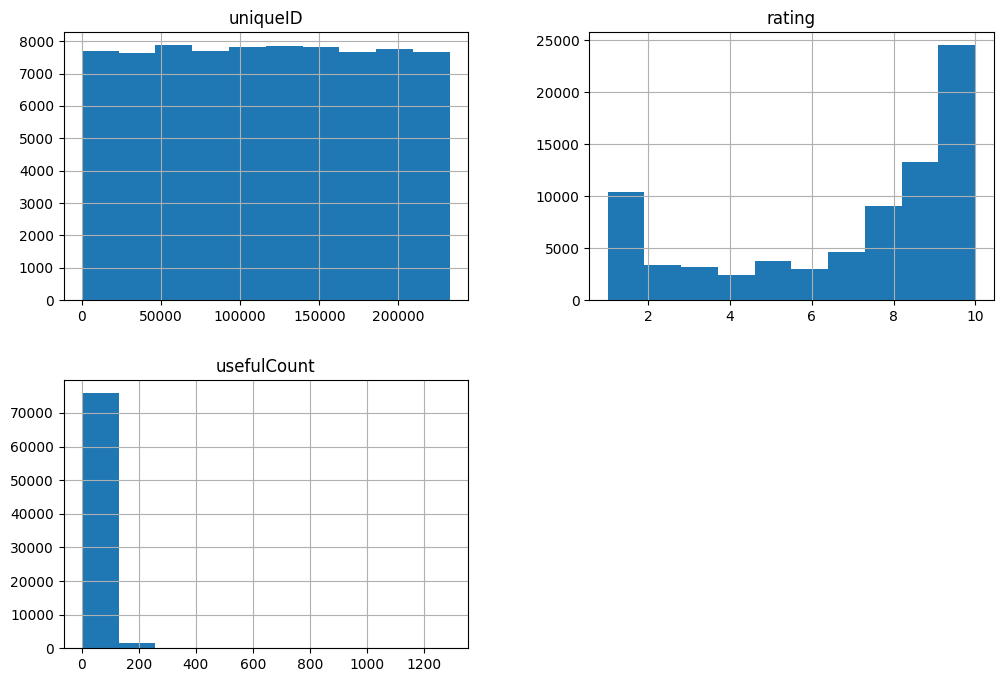

In [ ]:
df.hist(figsize=(12,8))
plt.show()

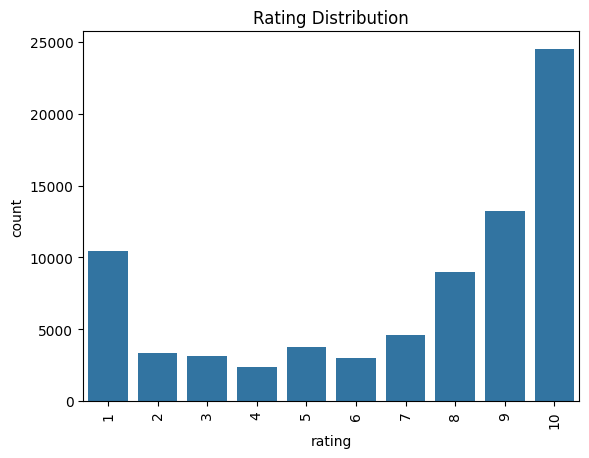

In [ ]:
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.xticks(rotation=90)
plt.show()

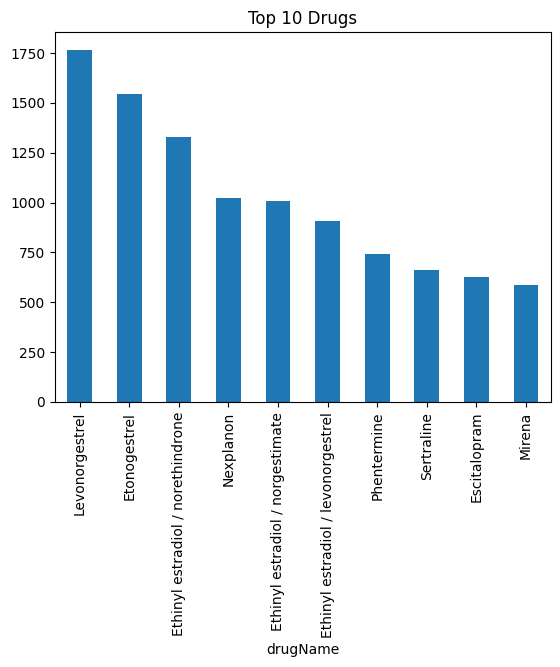

In [ ]:
df['drugName'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Drugs")
plt.show()

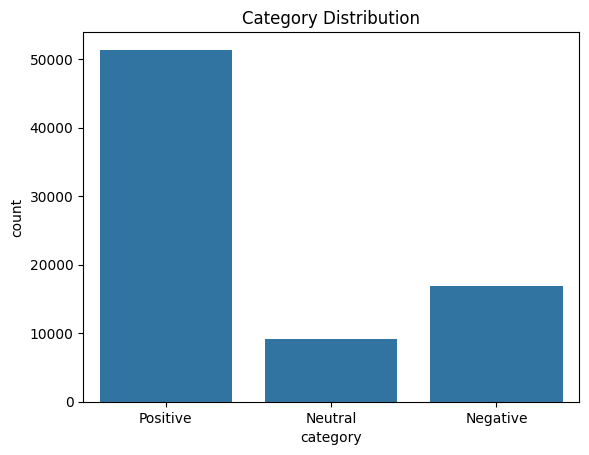

In [ ]:
sns.countplot(x='category', data=df)
plt.title("Category Distribution")
plt.show()

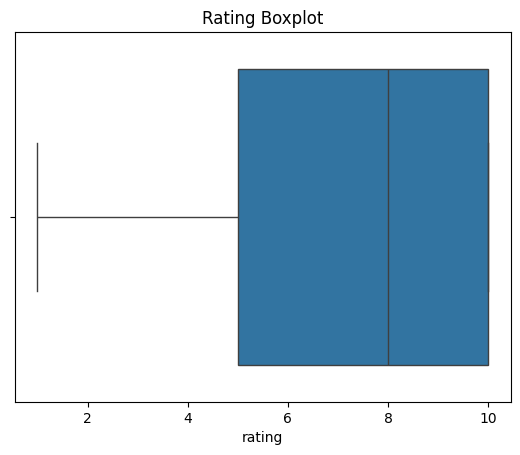

In [ ]:
sns.boxplot(x=df['rating'])
plt.title("Rating Boxplot")
plt.show()

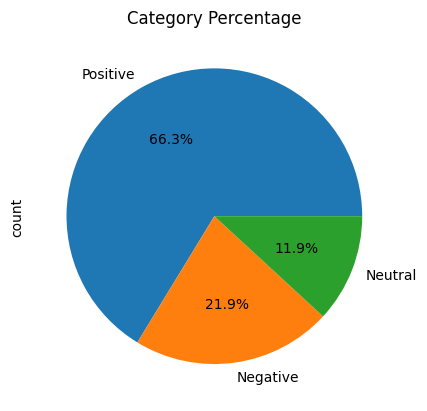

In [ ]:
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Percentage")
plt.show()

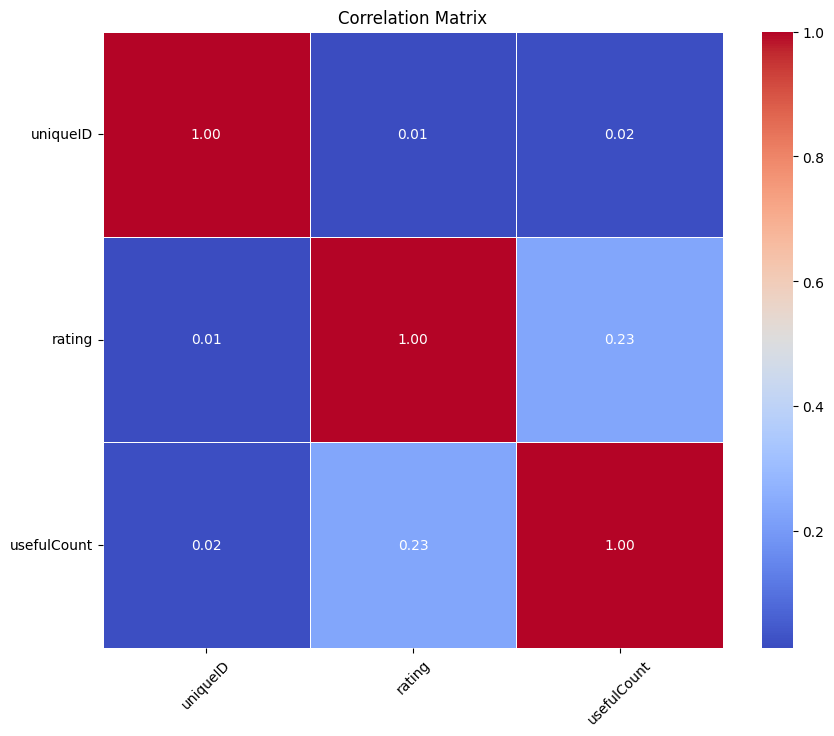

In [69]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
df_sample = df.sample(frac=0.2, random_state=42)
df_sample = df_sample.reset_index(drop=True)

In [ ]:
X = df_sample['review']
y = df_sample['rating']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.41


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.29419354838709677


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.40903225806451615


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC(kernel='linear')   # faster
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svc))

SVM Accuracy: 0.4067741935483871


In [ ]:
import pandas as pd

acc_df = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc)
    ]
})

print(acc_df)

           Model  Accuracy
0       Logistic  0.410000
1  Decision Tree  0.294194
2  Random Forest  0.409032
3            SVM  0.406774


In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.41
Precision: 0.32363182983994665
Recall   : 0.41
F1 Score : 0.3320812426172308


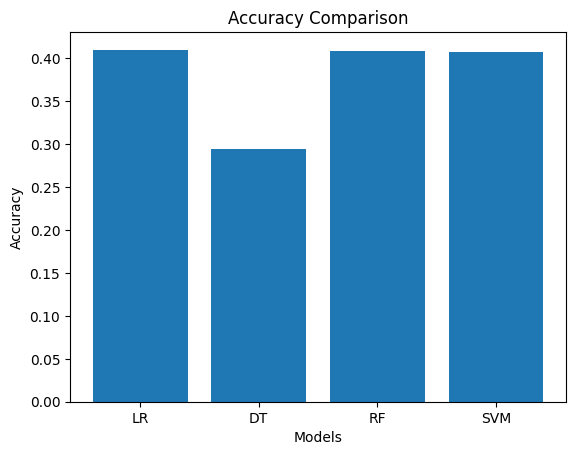

In [71]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svc.predict(X_test)
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)]
models = ["LR", "DT", "RF", "SVM"]
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

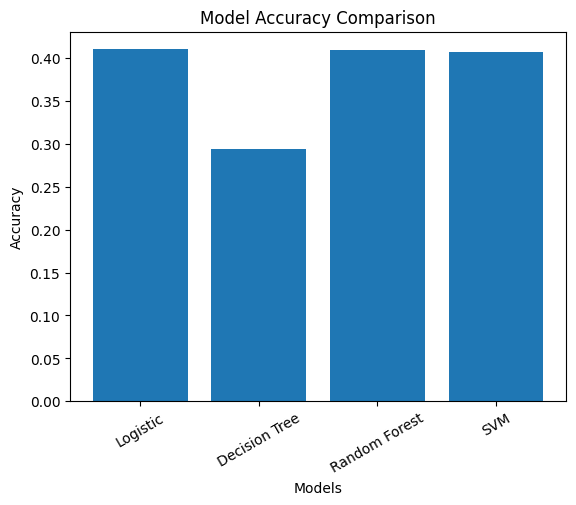

In [ ]:
plt.figure()
plt.bar(acc_df["Model"], acc_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

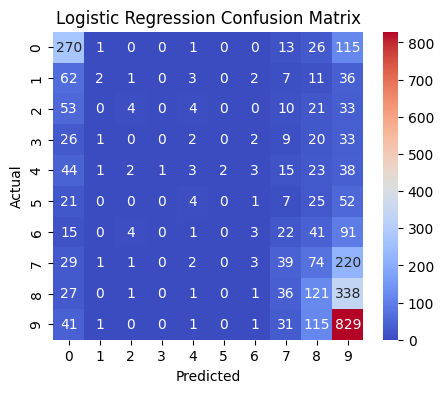

In [ ]:
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='coolwarm')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

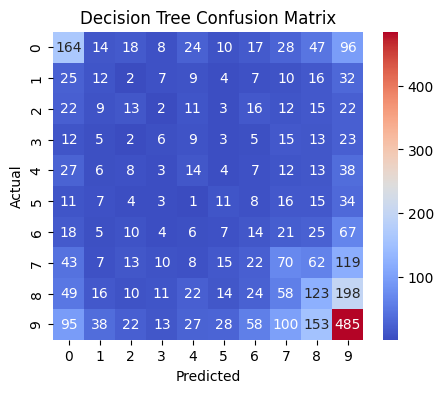

In [55]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='coolwarm')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

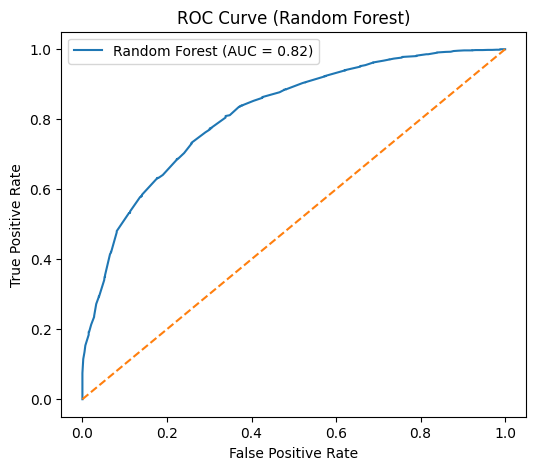

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
y_test_binary = (y_test >= 7).astype(int)
y_pred_proba_all_classes = rf.predict_proba(X_test)
model_classes = rf.classes_

positive_class_indices = [i for i, cls in enumerate(model_classes) if cls >= 7]

y_prob_binary = np.sum(y_pred_proba_all_classes[:, positive_class_indices], axis=1)
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_binary)
auc_score = roc_auc_score(y_test_binary, y_prob_binary)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.show()

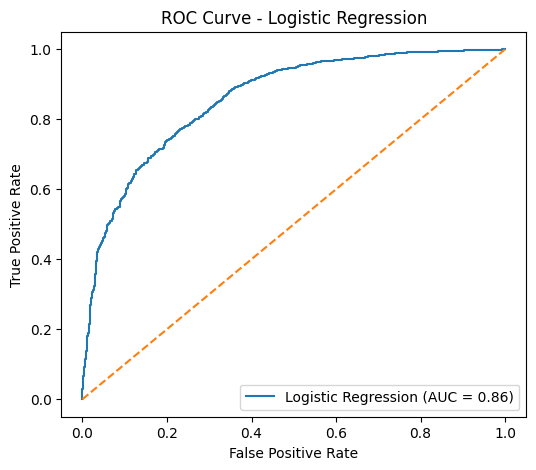

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

y_test_binary = (y_test >= 7).astype(int)
y_pred_proba_all_classes = lr.predict_proba(X_test)
model_classes = lr.classes_
positive_class_indices = [i for i, cls in enumerate(model_classes) if cls >= 7]
y_prob_lr_binary = np.sum(y_pred_proba_all_classes[:, positive_class_indices], axis=1)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_lr_binary)
auc_lr = roc_auc_score(y_test_binary, y_prob_lr_binary)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

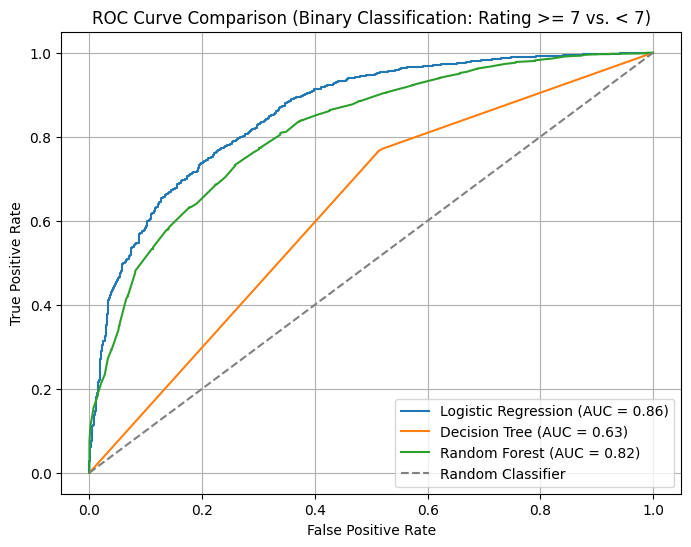

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
y_test_binary = (y_test >= 7).astype(int)
model_classes_lr = lr.classes_
positive_class_indices_lr = [i for i, cls in enumerate(model_classes_lr) if cls >= 7]

# Logistic Regression
y_pred_proba_all_classes_lr = lr.predict_proba(X_test)
y_prob_lr_binary = np.sum(y_pred_proba_all_classes_lr[:, positive_class_indices_lr], axis=1)
fpr_lr, tpr_lr, _ = roc_curve(y_test_binary, y_prob_lr_binary)
auc_lr = roc_auc_score(y_test_binary, y_prob_lr_binary)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")


# Decision Tree
model_classes_dt = dt.classes_
positive_class_indices_dt = [i for i, cls in enumerate(model_classes_dt) if cls >= 7]
y_pred_proba_all_classes_dt = dt.predict_proba(X_test)
y_prob_dt_binary = np.sum(y_pred_proba_all_classes_dt[:, positive_class_indices_dt], axis=1)
fpr_dt, tpr_dt, _ = roc_curve(y_test_binary, y_prob_dt_binary)
auc_dt = roc_auc_score(y_test_binary, y_prob_dt_binary)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")


# Random Forest
model_classes_rf = rf.classes_
positive_class_indices_rf = [i for i, cls in enumerate(model_classes_rf) if cls >= 7]
y_pred_proba_all_classes_rf = rf.predict_proba(X_test)
y_prob_rf_binary = np.sum(y_pred_proba_all_classes_rf[:, positive_class_indices_rf], axis=1)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, y_prob_rf_binary)
auc_rf = roc_auc_score(y_test_binary, y_prob_rf_binary)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Binary Classification: Rating >= 7 vs. < 7)")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
best_model = rf

prediction = best_model.predict(sample)
print("Final Prediction:", prediction)

Final Prediction: [10]


In [87]:
import joblib
joblib.dump(rf, "drugsComTrain_raw.pkl")

['drugsComTrain_raw.pkl']